In [21]:
import sys, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from data_loader import (
    load_fer2013_train_val, load_fer2013_test,
    get_class_distribution, save_processed,
    EMOTION_LABELS, STRESS_MAP, EMOTION_VALENCE,
    DATA_RAW, DATA_PROC, CNN_WEIGHT, PHYSIO_WEIGHT,
)
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'CNN Branch weight  : {CNN_WEIGHT*100:.0f}%')
print(f'Physio Branch weight: {PHYSIO_WEIGHT*100:.0f}%')
print('Imports OK')

PROJECT_ROOT: /home/ariba/Projects/stress_detection_project - Multi Factor
CNN Branch weight  : 20%
Physio Branch weight: 80%
Imports OK


In [22]:
print('Checking data/raw/ structure...')
for split in ['train', 'test']:
    split_dir = DATA_RAW / split
    if not split_dir.exists():
        print(f'MISSING: {split_dir}')
    else:
        emotions = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
        counts = {e: len(list((split_dir/e).glob('*.jpg')) +
                         list((split_dir/e).glob('*.png')))
                  for e in emotions}
        print(f'{split}: {counts}')

Checking data/raw/ structure...
train: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
test: {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


In [23]:
train_images, train_labels, val_images, val_labels = load_fer2013_train_val(val_split=0.1)
print(f'train: {train_images.shape}  val: {val_images.shape}')

Loading TRAIN images from: /home/ariba/Projects/stress_detection_project - Multi Factor/data/raw/train
   angry        →  3995 images  (label 0, valence=1.0)
   disgust      →   436 images  (label 1, valence=1.0)
   fear         →  4097 images  (label 2, valence=1.0)
   happy        →  7215 images  (label 3, valence=0.0)
   neutral      →  4965 images  (label 6, valence=0.0)
   sad          →  4830 images  (label 4, valence=0.5)
   surprise     →  3171 images  (label 5, valence=0.5)

Loaded [train]: (28709, 48, 48)  labels: (28709,)

   Train : (25838, 48, 48)
   Val   : (2871, 48, 48)  (10% of train)
train: (25838, 48, 48)  val: (2871, 48, 48)


In [24]:
test_images, test_labels = load_fer2013_test()
print(f'test: {test_images.shape}')

Loading TEST images from: /home/ariba/Projects/stress_detection_project - Multi Factor/data/raw/test


   angry        →   958 images  (label 0, valence=1.0)
   disgust      →   111 images  (label 1, valence=1.0)
   fear         →  1024 images  (label 2, valence=1.0)
   happy        →  1774 images  (label 3, valence=0.0)
   neutral      →  1233 images  (label 6, valence=0.0)
   sad          →  1247 images  (label 4, valence=0.5)
   surprise     →   831 images  (label 5, valence=0.5)

Loaded [test]: (7178, 48, 48)  labels: (7178,)
test: (7178, 48, 48)


In [25]:
print('=== TRAIN ===')
get_class_distribution(train_labels)
print('\nCNN Branch: Emotion → Stress Valence Map')
for cls_idx, name in EMOTION_LABELS.items():
    stress_label, _ = STRESS_MAP[name]
    valence = EMOTION_VALENCE[name]
    print(f'  {name:<12} {stress_label:<10} valence={valence:.1f}')

=== TRAIN ===

Class Distribution:
   Emotion       Count       %   Valence
   --------------------------------------
   Angry          3601   13.9%      1.00
   Disgust         386    1.5%      1.00
   Fear           3715   14.4%      1.00
   Happy          6486   25.1%      0.00
   Sad            4339   16.8%      0.50
   Surprise       2859   11.1%      0.50
   Neutral        4452   17.2%      0.00


CNN Branch: Emotion → Stress Valence Map
  Angry        High       valence=1.0
  Disgust      High       valence=1.0
  Fear         High       valence=1.0
  Happy        Low        valence=0.0
  Sad          Medium     valence=0.5
  Surprise     Medium     valence=0.5
  Neutral      Low        valence=0.0


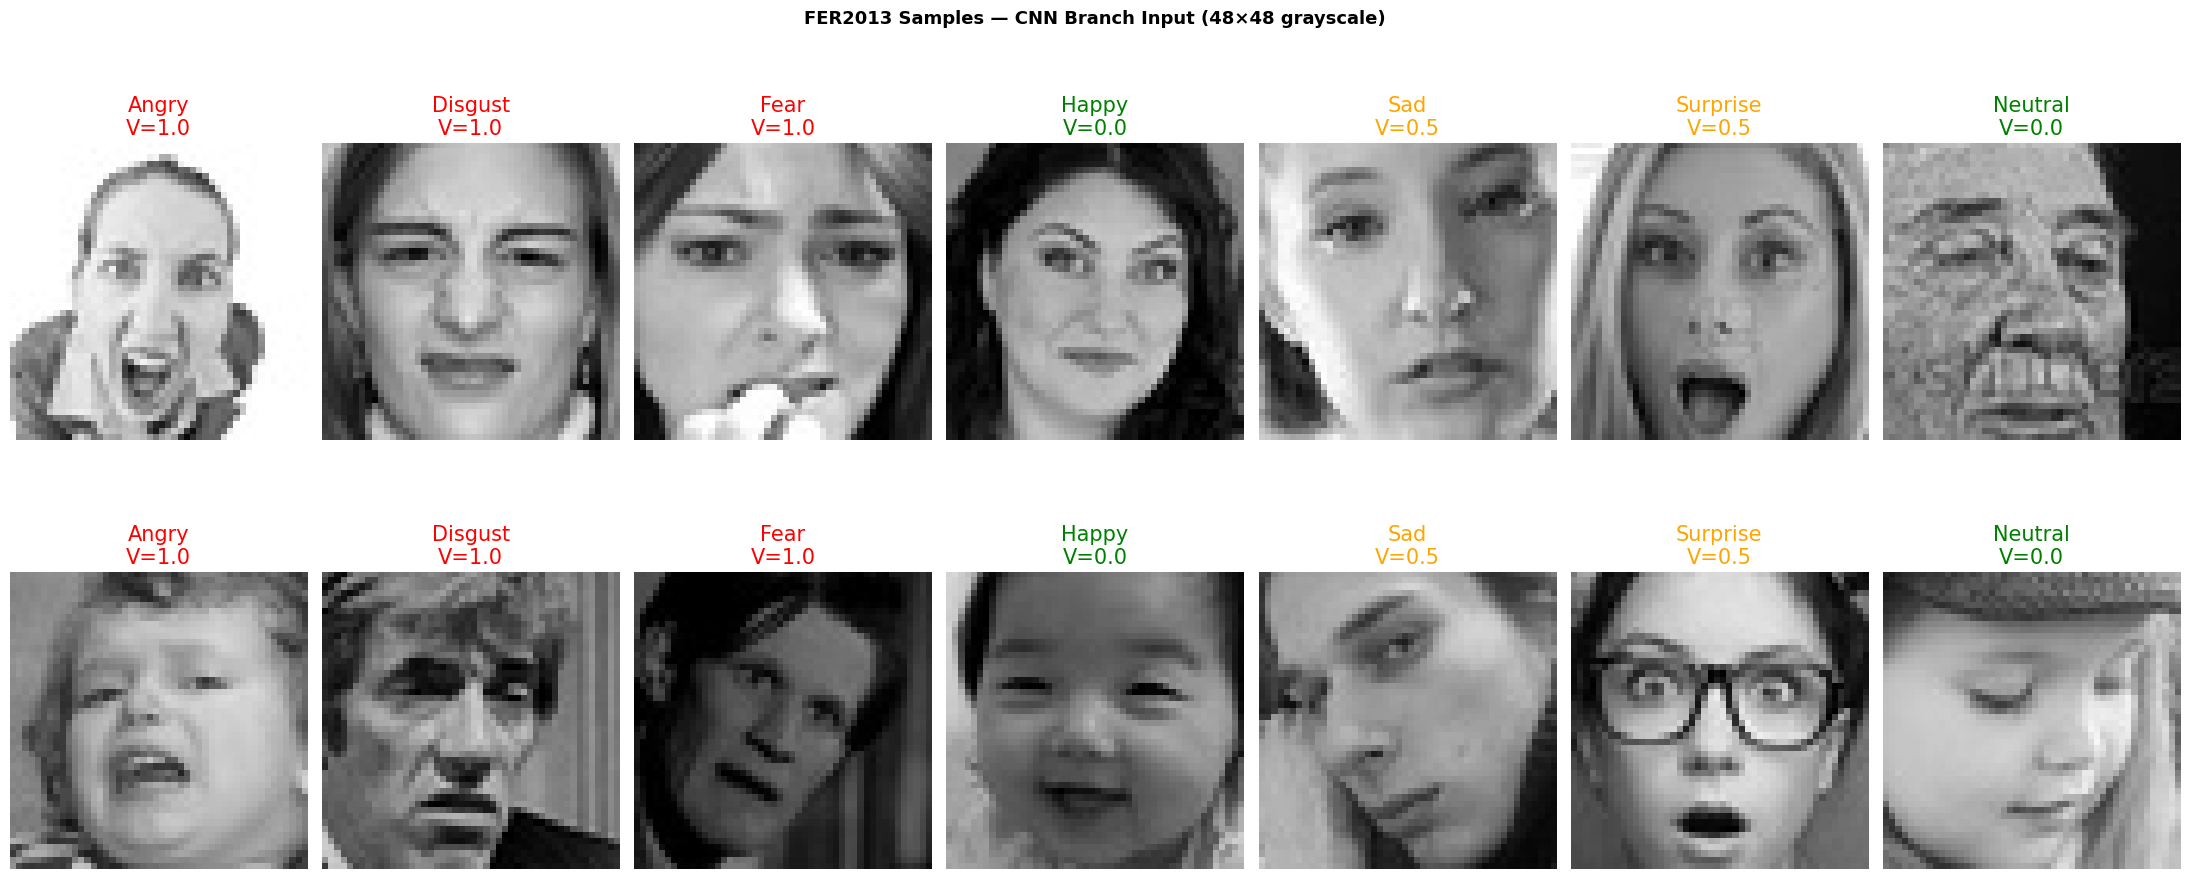

Saved → outputs/sample_images.png


In [26]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 7, figsize=(22, 10))
fig.suptitle('FER2013 Samples — CNN Branch Input (48×48 grayscale)', fontsize=13, fontweight='bold')
emotion_names = [EMOTION_LABELS[i] for i in range(7)]
color_map = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}
for row in range(2):
    for col, emo_idx in enumerate(range(7)):
        ax = axes[row, col]
        mask = train_labels == emo_idx
        idxs = np.where(mask)[0]
        if len(idxs) == 0:
            ax.axis('off'); continue
        img = train_images[idxs[(row*7+col) % len(idxs)]]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        name = emotion_names[emo_idx]
        stress, _ = STRESS_MAP[name]
        ax.set_title(f'{name}\nV={EMOTION_VALENCE[name]:.1f}', fontsize=15,
                     color=color_map[stress])
        ax.axis('off')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'outputs' / 'sample_images.png'), dpi=120)
plt.show()
print('Saved → outputs/sample_images.png')

In [28]:
save_processed(train_images, train_labels, 'train_raw')
save_processed(val_images,   val_labels,   'val_raw')
save_processed(test_images,  test_labels,  'test_raw')

Saved train_raw: train_raw_images.npy, train_raw_labels.npy
Saved val_raw: val_raw_images.npy, val_raw_labels.npy
Saved test_raw: test_raw_images.npy, test_raw_labels.npy
